Here we will be analysing the channel for SNR of 2dB see which model we are dealing with

In [60]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.stats import binom

In [30]:
snr = 2

In [89]:
with h5py.File("simulation.h5", "a") as f:
    def print_tree(name, obj):
        print(name)
    # f.visititems(print_tree)
    f.attrs["discriptor"] = "BMOCZ channel process analysis data"
    data_2 = f["data"][f"{snr}"]
    data_2Keys = list(data_2.keys())
    # msg = data_2["msg"][:]
    error_vec = data_2["error_vec"][:]
    # decoded_msg = data_2["decoded_msg"][:]
    params = list( f["parameters"].keys() )

In [91]:
with h5py.File("simulation.h5", "a") as f:
    def print_tree(name, obj):
        print(name)
    f.visititems(print_tree)

data
data/-1
data/-1/decoded_msg
data/-1/error_vec
data/-1/msg
data/-10
data/-10/decoded_msg
data/-10/error_vec
data/-10/msg
data/-2
data/-2/decoded_msg
data/-2/error_vec
data/-2/msg
data/-3
data/-3/decoded_msg
data/-3/error_vec
data/-3/msg
data/-4
data/-4/decoded_msg
data/-4/error_vec
data/-4/msg
data/-5
data/-5/decoded_msg
data/-5/error_vec
data/-5/msg
data/-6
data/-6/decoded_msg
data/-6/error_vec
data/-6/msg
data/-7
data/-7/decoded_msg
data/-7/error_vec
data/-7/msg
data/-8
data/-8/decoded_msg
data/-8/error_vec
data/-8/msg
data/-9
data/-9/decoded_msg
data/-9/error_vec
data/-9/msg
data/0
data/0/decoded_msg
data/0/error_vec
data/0/msg
data/1
data/1/decoded_msg
data/1/error_vec
data/1/msg
data/10
data/10/decoded_msg
data/10/error_vec
data/10/msg
data/11
data/11/decoded_msg
data/11/error_vec
data/11/msg
data/12
data/12/decoded_msg
data/12/error_vec
data/12/msg
data/13
data/13/decoded_msg
data/13/error_vec
data/13/msg
data/14
data/14/decoded_msg
data/14/error_vec
data/14/msg
data/15
data/

In [43]:
print(data_2Keys)
print(type(error_vec), error_vec.shape)

ber = error_vec.mean()
print(f"\n BER at SNR - {snr}dB: {ber}")

err_pkt = np.count_nonzero(error_vec, axis=1)  # axis = 1 for rows
print(f"\n Number of error packets: {np.count_nonzero(err_pkt)}")
per = np.count_nonzero(err_pkt) / err_pkt.size
print(f"    PER at SNR - {snr}dB: {per}")

BitBER = error_vec.mean(axis=0)
print(f"\n Per bit BER: {BitBER}")

['decoded_msg', 'error_vec', 'msg']
<class 'numpy.ndarray'> (100000, 32)

 BER at SNR - 2dB: 0.190824375

 Number of error packets: 88662
    PER at SNR - 2dB: 0.88662

 Per bit BER: [0.19117 0.19132 0.18865 0.19026 0.18961 0.19146 0.19054 0.18922 0.18878
 0.19149 0.18815 0.19077 0.19005 0.19247 0.19118 0.1911  0.19169 0.19167
 0.19333 0.19236 0.19063 0.19105 0.19276 0.18965 0.18875 0.19053 0.19197
 0.19127 0.19125 0.19167 0.19101 0.19057]


- PER is confirmed with the simulations made and it is quite high

- while the per bit BER is same as the BER. Is it something crucial?

In [47]:
err_wtMean = err_pkt.mean()
err_wtVar = err_pkt.var()
print(f"Mean number of errored bits per packet are: {err_wtMean}, Variance: {err_wtVar}")
print(f"Maximum number of errors per packet: {err_pkt.max()}")
print(f"Minimum number of errors per packet: {err_pkt.min()}")

Mean number of errored bits per packet are: 6.10638, Variance: 25.3482232956
Maximum number of errors per packet: 25
Minimum number of errors per packet: 0


In [80]:
print(binom.pmf(1, 10, ber))
print(err_pkt.mean()/32)

0.2838043031011622
0.190824375


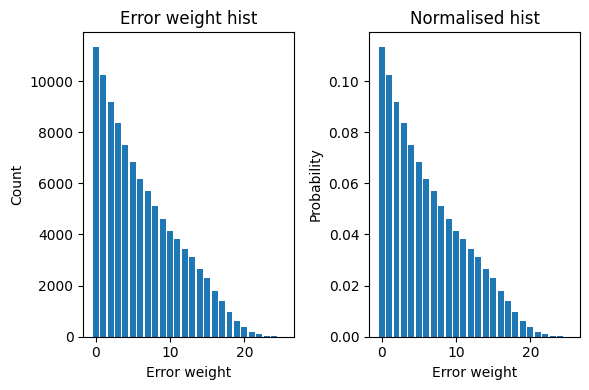

In [59]:
values, count = np.unique(err_pkt, return_counts=True)
prob = count / err_pkt.size

fig, ax = plt.subplots(1,2, figsize=(6,4))

ax[0].bar(values, count)
ax[0].set_title("Error weight hist")
ax[0].set_xlabel("Error weight")
ax[0].set_ylabel("Count")

ax[1].bar(values, prob)
ax[1].set_title("Normalised hist")
ax[1].set_xlabel("Error weight")
ax[1].set_ylabel("Probability")

plt.tight_layout()
plt.show()